# 🧠 HVAC Anomaly Detection — Step 3b: LSTM Autoencoder
**Input:** preprocessed arrays from Step 2  
**Goal:** Learn normal HVAC patterns, flag windows with high reconstruction error

### Why LSTM Autoencoder?
- **LSTM** remembers sequence patterns (6am ON, 7pm OFF, weekday cycles)
- **Autoencoder** learns to compress → reconstruct normal data
- When it sees an anomaly it can't reconstruct well → high error → anomaly flag
- Fixes Isolation Forest's weakness: **temporal context**, not just summary stats

### How it works
```
Input window          Encoder            Bottleneck        Decoder           Reconstructed
(96 × 5)      →   LSTM layers    →   (compressed)   →  LSTM layers   →      (96 × 5)
                  learn patterns      representation    reconstruct           ↓
                                                                       compare with input
                                                                       MSE error per window
                                                                       high error = anomaly
```
---

## 0. Install & Import Libraries

In [6]:
# Install PyTorch (CPU version — no GPU needed for this dataset size)
# Run this cell first, then restart kernel, then run all cells below
!pip install torch --index-url https://download.pytorch.org/whl/cpu
!pip install numpy pandas matplotlib seaborn scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cpu

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All imports OK")
print(f"   PyTorch version : {torch.__version__}")
print(f"   Device          : {DEVICE}")
print(f"   CUDA available  : {torch.cuda.is_available()}")

✅ All imports OK
   PyTorch version : 2.12.0
   Device          : cpu
   CUDA available  : False


## 1. Load Preprocessed Data

In [8]:
PREPROCESSED_DIR = 'preprocessed'   # ← update path if needed
FEATURES = ['T_Supply', 'T_Return', 'T_Outdoor', 'Power', 'T_delta']

X_train = np.load(f'{PREPROCESSED_DIR}/X_train.npy')  # (3366, 96, 5)
X_val   = np.load(f'{PREPROCESSED_DIR}/X_val.npy')    # (842,  96, 5)
X_test  = np.load(f'{PREPROCESSED_DIR}/X_test.npy')   # (4238, 96, 5)
ts_test = pd.to_datetime(
    pd.read_csv(f'{PREPROCESSED_DIR}/test_timestamps.csv')['timestamp'])

print(f"X_train : {X_train.shape}  ← model learns normal from this")
print(f"X_val   : {X_val.shape}   ← tune threshold")
print(f"X_test  : {X_test.shape}  ← contains real anomalies")
print(f"\nEach window: {X_train.shape[1]} timesteps × {X_train.shape[2]} features")
print(f"             = {X_train.shape[1]} × 15min = 24 hours of data")

X_train : (3366, 96, 5)  ← model learns normal from this
X_val   : (842, 96, 5)   ← tune threshold
X_test  : (4238, 96, 5)  ← contains real anomalies

Each window: 96 timesteps × 5 features
             = 96 × 15min = 24 hours of data


## 2. Create PyTorch DataLoaders
Convert numpy arrays → PyTorch tensors → DataLoader for batch training.

In [9]:
BATCH_SIZE = 64

def make_loader(X, shuffle=True):
    tensor = torch.FloatTensor(X)
    dataset = TensorDataset(tensor, tensor)  # input = target (autoencoder)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

train_loader = make_loader(X_train, shuffle=True)
val_loader   = make_loader(X_val,   shuffle=False)
test_loader  = make_loader(X_test,  shuffle=False)

print(f"Train batches : {len(train_loader)}  (batch_size={BATCH_SIZE})")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 53  (batch_size=64)
Val batches   : 14
Test batches  : 67


## 3. LSTM Autoencoder Architecture

```
INPUT  (batch, 96, 5)
    ↓
ENCODER
  LSTM(5 → 64)   → processes sequence forward, learns temporal patterns
  LSTM(64 → 32)  → compresses to smaller representation
  take last hidden state → bottleneck (batch, 32)
    ↓
BOTTLENECK  (batch, 32)  ← compressed representation of the 24h window
    ↓
DECODER
  repeat bottleneck 96 times → (batch, 96, 32)
  LSTM(32 → 64)  → start reconstructing
  LSTM(64 → 5)   → reconstruct original 5 features
    ↓
OUTPUT (batch, 96, 5)  ← reconstructed window
    ↓
LOSS = MSE(output, input)  ← how well did it reconstruct?
```

In [10]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=5, hidden_dim=64, bottleneck_dim=32,
                 n_layers=2, dropout=0.2):
        super().__init__()
        self.n_features    = n_features
        self.hidden_dim    = hidden_dim
        self.bottleneck_dim = bottleneck_dim
        self.n_layers      = n_layers
        self.seq_len       = 96   # window size

        # ── Encoder ──────────────────────────────────────────────────────
        self.encoder_lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,         # (batch, seq, feature)
            dropout=dropout if n_layers > 1 else 0,
        )
        self.encoder_fc = nn.Linear(hidden_dim, bottleneck_dim)

        # ── Decoder ──────────────────────────────────────────────────────
        self.decoder_fc = nn.Linear(bottleneck_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.output_fc = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        # x shape: (batch, seq_len, n_features)
        batch_size = x.size(0)

        # Encode: run LSTM, take last hidden state
        _, (hidden, _) = self.encoder_lstm(x)
        # hidden: (n_layers, batch, hidden_dim) — take last layer
        bottleneck = self.encoder_fc(hidden[-1])    # (batch, bottleneck_dim)

        # Decode: repeat bottleneck across time steps
        dec_input = self.decoder_fc(bottleneck)         # (batch, hidden_dim)
        dec_input = dec_input.unsqueeze(1).repeat(1, self.seq_len, 1)
        # (batch, seq_len, hidden_dim)

        dec_output, _ = self.decoder_lstm(dec_input)    # (batch, seq_len, hidden_dim)
        reconstruction = self.output_fc(dec_output)     # (batch, seq_len, n_features)
        return reconstruction

# ── Instantiate & inspect ─────────────────────────────────────────────────
model = LSTMAutoencoder(
    n_features=5,
    hidden_dim=64,
    bottleneck_dim=32,
    n_layers=2,
    dropout=0.2
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# Quick sanity check: one forward pass
dummy = torch.randn(4, 96, 5).to(DEVICE)
out   = model(dummy)
print(f"Input shape : {dummy.shape}")
print(f"Output shape: {out.shape}  ← must match input ✅")

LSTMAutoencoder(
  (encoder_lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (encoder_fc): Linear(in_features=64, out_features=32, bias=True)
  (decoder_fc): Linear(in_features=32, out_features=64, bias=True)
  (decoder_lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
  (output_fc): Linear(in_features=64, out_features=5, bias=True)
)

Total trainable parameters: 122,533
Input shape : torch.Size([4, 96, 5])
Output shape: torch.Size([4, 96, 5])  ← must match input ✅


## 4. Training
The model trains to minimize **reconstruction error (MSE)** on normal windows only.  
After training, anything it reconstructs poorly = anomaly.

In [11]:
# ── Hyperparameters ──────────────────────────────────────────────────────
EPOCHS    = 50
LR        = 1e-3
PATIENCE  = 7    # early stopping — stop if val loss doesn't improve for 7 epochs

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

# ── Training loop ─────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Training LSTM Autoencoder for up to {EPOCHS} epochs...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'LR':>12} {'Status':>10}")
print("-" * 56)

for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    batch_losses = []
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        optimizer.zero_grad()
        reconstructed = model(x_batch)
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(DEVICE)
            reconstructed = model(x_batch)
            loss = criterion(reconstructed, x_batch)
            val_batch_losses.append(loss.item())
    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # ── Early stopping ────────────────────────────────────────────────────
    status = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        status = '✅ best'
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    current_lr = optimizer.param_groups[0]['lr']
    if epoch % 5 == 0 or epoch == 1 or status:
        print(f"{epoch:>6} {train_loss:>12.6f} {val_loss:>12.6f} "
              f"{current_lr:>12.2e} {status:>10}")

# Restore best model
model.load_state_dict(best_model_state)
print(f"\n✅ Training complete. Best val loss: {best_val_loss:.6f}")

Training LSTM Autoencoder for up to 50 epochs...
 Epoch   Train Loss     Val Loss           LR     Status
--------------------------------------------------------
     1     0.095855     0.089359     1.00e-03     ✅ best
     2     0.066863     0.082563     1.00e-03     ✅ best
     4     0.057646     0.077427     1.00e-03     ✅ best
     5     0.056274     0.076812     1.00e-03     ✅ best
     6     0.056860     0.075783     1.00e-03     ✅ best
     8     0.054615     0.075115     1.00e-03     ✅ best
    10     0.053187     0.078404     1.00e-03           
    11     0.052864     0.074461     1.00e-03     ✅ best
    12     0.052410     0.069280     1.00e-03     ✅ best
    14     0.052310     0.068635     1.00e-03     ✅ best
    15     0.050753     0.067785     1.00e-03     ✅ best
    16     0.050630     0.066388     1.00e-03     ✅ best
    20     0.049139     0.067676     5.00e-04           
    21     0.048921     0.066060     5.00e-04     ✅ best
    22     0.048743     0.065031     5.

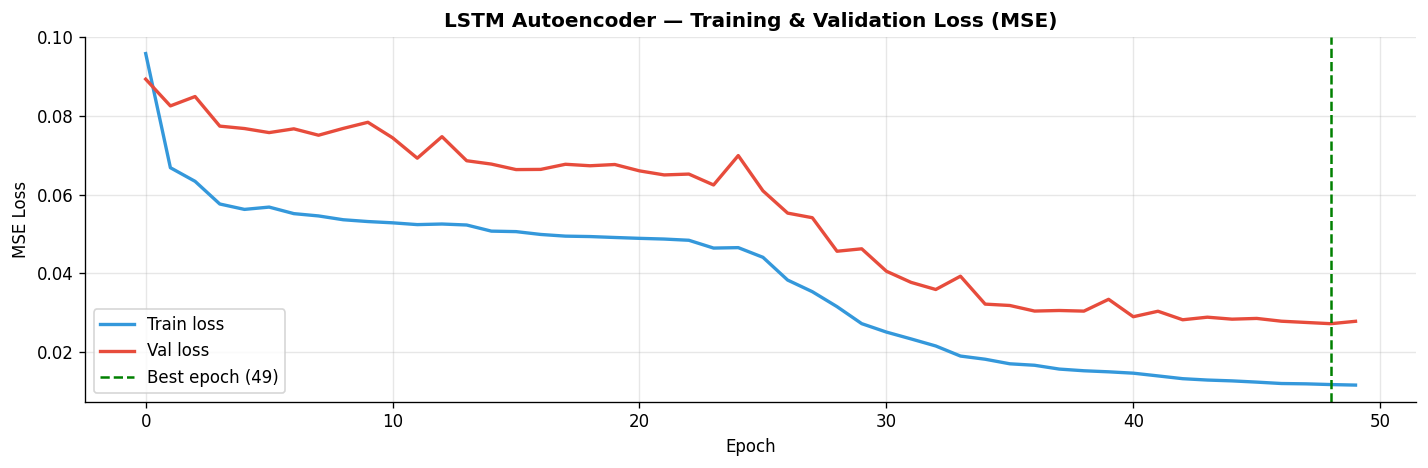

Best epoch    : 49
Best val loss : 0.027242


In [12]:
# Plot training curves
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_losses, label='Train loss', color='#3498db', linewidth=2)
ax.plot(val_losses,   label='Val loss',   color='#e74c3c', linewidth=2)
ax.set_title('LSTM Autoencoder — Training & Validation Loss (MSE)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(fontsize=10)
best_epoch = np.argmin(val_losses)
ax.axvline(best_epoch, color='green', linewidth=1.5, linestyle='--',
           label=f'Best epoch ({best_epoch+1})')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('lstm_01_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Best epoch    : {best_epoch + 1}")
print(f"Best val loss : {val_losses[best_epoch]:.6f}")

## 5. Compute Reconstruction Errors
For every window in train, val, and test — compute the MSE between input and reconstruction.  
**High MSE = model struggled to reconstruct = anomaly.**

In [13]:
def get_reconstruction_errors(loader, model, device):
    """Returns per-window MSE reconstruction error."""
    model.eval()
    errors = []
    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            # MSE per window (mean over timesteps and features)
            mse = ((recon - x_batch) ** 2).mean(dim=(1, 2))
            errors.extend(mse.cpu().numpy())
    return np.array(errors)

errors_train = get_reconstruction_errors(train_loader, model, DEVICE)
errors_val   = get_reconstruction_errors(val_loader,   model, DEVICE)
errors_test  = get_reconstruction_errors(test_loader,  model, DEVICE)

print(f"Train errors — mean: {errors_train.mean():.5f}  std: {errors_train.std():.5f}"
      f"  max: {errors_train.max():.5f}")
print(f"Val   errors — mean: {errors_val.mean():.5f}  std: {errors_val.std():.5f}"
      f"  max: {errors_val.max():.5f}")
print(f"Test  errors — mean: {errors_test.mean():.5f}  std: {errors_test.std():.5f}"
      f"  max: {errors_test.max():.5f}")

Train errors — mean: 0.01036  std: 0.00935  max: 0.07325
Val   errors — mean: 0.02522  std: 0.01911  max: 0.08675
Test  errors — mean: 0.04313  std: 0.03387  max: 0.16190


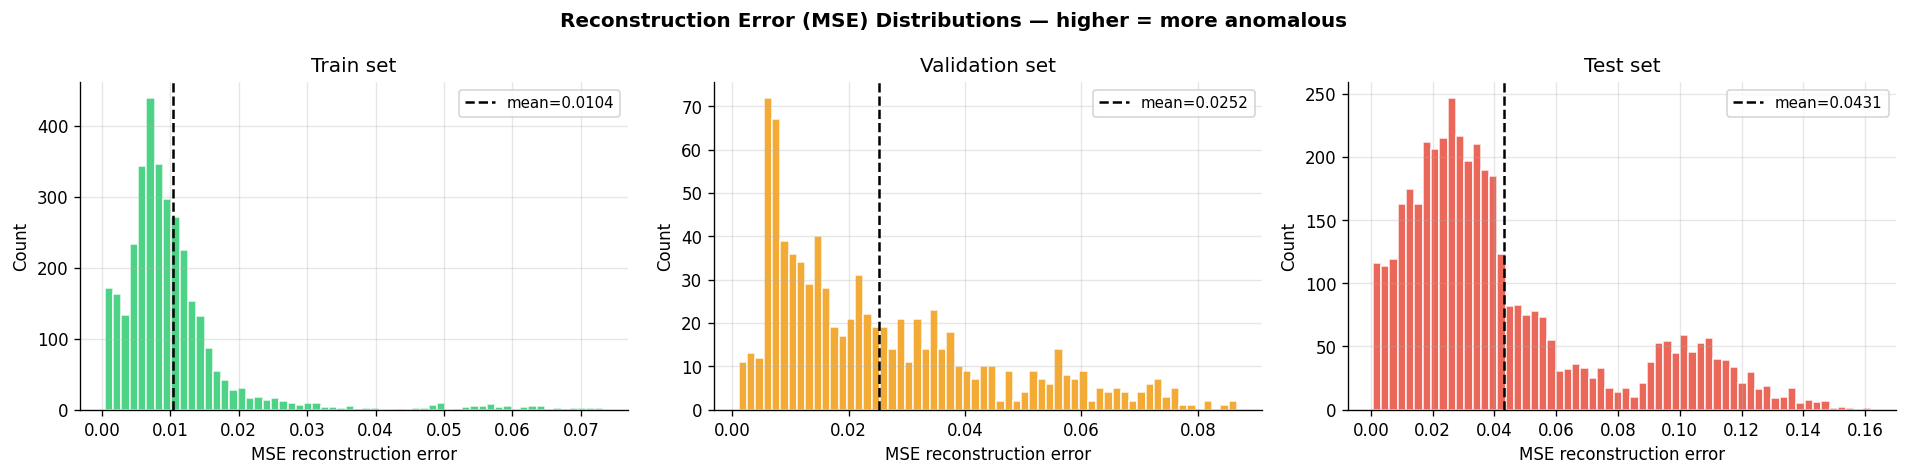

In [14]:
# Plot reconstruction error distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Reconstruction Error (MSE) Distributions — higher = more anomalous',
             fontsize=12, fontweight='bold')

for ax, errors, label, c in zip(axes,
    [errors_train, errors_val, errors_test],
    ['Train', 'Validation', 'Test'],
    ['#2ecc71', '#f39c12', '#e74c3c']):
    ax.hist(errors, bins=60, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(errors.mean(), color='black', linewidth=1.5,
               linestyle='--', label=f'mean={errors.mean():.4f}')
    ax.set_title(f'{label} set')
    ax.set_xlabel('MSE reconstruction error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('lstm_02_error_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Anomaly Threshold — Set from Validation Set
We set the threshold as **mean + k × std** of validation errors.  
`k` controls sensitivity:
- Higher k → fewer anomalies flagged (fewer false positives)
- Lower k → more anomalies flagged (fewer false negatives)

We sweep k and pick based on a reasonable anomaly rate (~2–8%).

In [15]:
print(f"Val error stats: mean={errors_val.mean():.5f}  std={errors_val.std():.5f}")
print()
print(f"{'k':>5} {'Threshold':>12} {'Test flagged':>14} {'Anomaly %':>12}")
print("-" * 48)

for k in [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    thresh = errors_val.mean() + k * errors_val.std()
    flagged = (errors_test > thresh).sum()
    pct = flagged / len(errors_test) * 100
    print(f"{k:>5.1f} {thresh:>12.6f} {flagged:>14,} {pct:>11.1f}%")

Val error stats: mean=0.02522  std=0.01911

    k    Threshold   Test flagged    Anomaly %
------------------------------------------------
  1.0     0.044334          1,372        32.4%
  1.5     0.053890          1,083        25.6%
  2.0     0.063445            898        21.2%
  2.5     0.073000            788        18.6%
  3.0     0.082555            711        16.8%
  3.5     0.092110            632        14.9%
  4.0     0.101666            448        10.6%


In [16]:
# Choose k — aim for 2–8% anomaly rate
K = 2.5
THRESHOLD = errors_val.mean() + K * errors_val.std()

test_anomaly_labels = (errors_test > THRESHOLD).astype(int)
n_anomalies = test_anomaly_labels.sum()

print(f"Chosen k         : {K}")
print(f"Threshold        : {THRESHOLD:.6f}")
print(f"Anomalies flagged: {n_anomalies:,} / {len(test_anomaly_labels):,} "
      f"({n_anomalies/len(test_anomaly_labels)*100:.1f}%)")

Chosen k         : 2.5
Threshold        : 0.073000
Anomalies flagged: 788 / 4,238 (18.6%)


## 7. Anomaly Detection Timeline
Plot reconstruction errors over time with anomaly flags overlaid on raw signals.

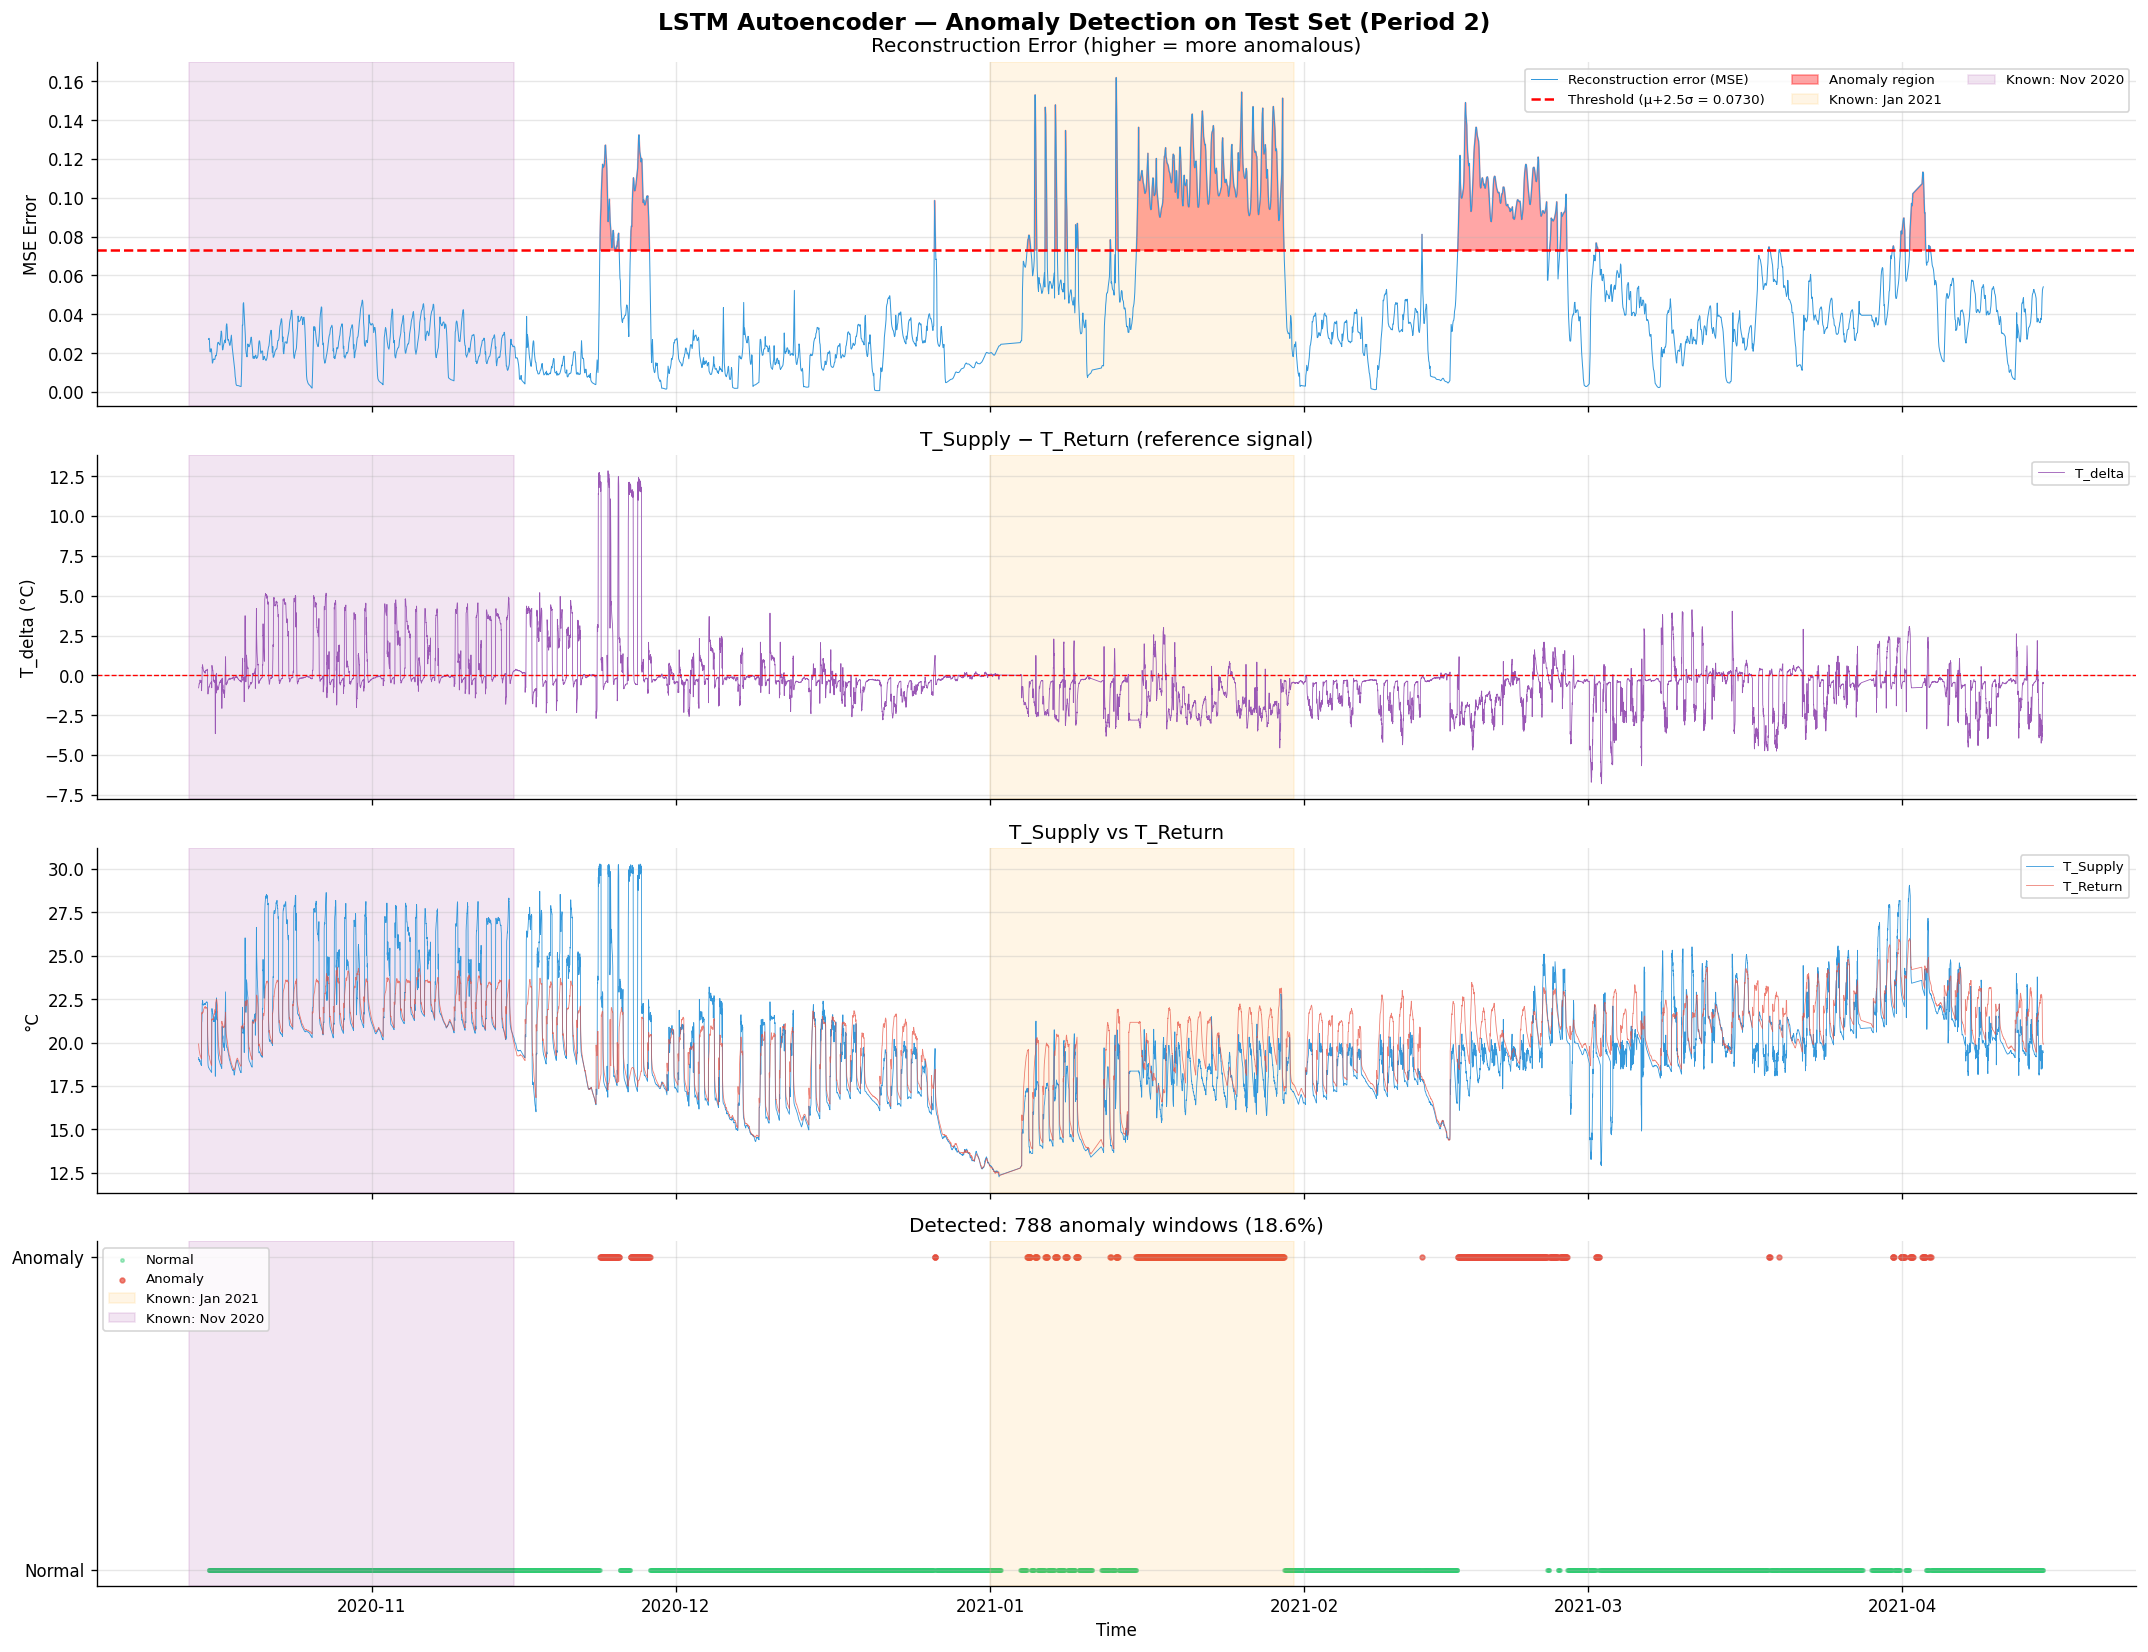

In [17]:
# Load raw Period 2 data for context panels
df_raw = pd.read_csv('HVAC_NE_EC_19-21.csv')
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'], utc=True)
df_raw = df_raw.set_index('Timestamp').sort_index()
df_raw['T_delta'] = df_raw['T_Supply'] - df_raw['T_Return']
p2_raw = df_raw[df_raw.index >= pd.Timestamp('2020-10-14', tz='UTC')]

# Known anomaly regions
jan_start = pd.Timestamp('2021-01-01', tz='UTC')
jan_end   = pd.Timestamp('2021-01-31', tz='UTC')
nov_start = pd.Timestamp('2020-10-14', tz='UTC')
nov_end   = pd.Timestamp('2020-11-15', tz='UTC')

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
fig.suptitle('LSTM Autoencoder — Anomaly Detection on Test Set (Period 2)',
             fontsize=14, fontweight='bold')

# Panel 1: Reconstruction error
ax = axes[0]
ax.plot(ts_test, errors_test, color='#3498db', linewidth=0.6,
        label='Reconstruction error (MSE)')
ax.axhline(THRESHOLD, color='red', linewidth=1.5, linestyle='--',
           label=f'Threshold (μ+{K}σ = {THRESHOLD:.4f})')
ax.fill_between(ts_test, errors_test, THRESHOLD,
                where=(errors_test > THRESHOLD),
                color='red', alpha=0.35, label='Anomaly region')
ax.axvspan(jan_start, jan_end, alpha=0.1, color='orange', label='Known: Jan 2021')
ax.axvspan(nov_start, nov_end, alpha=0.1, color='purple', label='Known: Nov 2020')
ax.set_ylabel('MSE Error')
ax.legend(fontsize=8, loc='upper right', ncol=3)
ax.set_title('Reconstruction Error (higher = more anomalous)')

# Panel 2: T_delta raw
ax = axes[1]
ax.plot(p2_raw.index, p2_raw['T_delta'], color='#9b59b6', linewidth=0.5, label='T_delta')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.axvspan(jan_start, jan_end, alpha=0.1, color='orange')
ax.axvspan(nov_start, nov_end, alpha=0.1, color='purple')
ax.set_ylabel('T_delta (°C)')
ax.legend(fontsize=8)
ax.set_title('T_Supply − T_Return (reference signal)')

# Panel 3: T_Supply vs T_Return
ax = axes[2]
ax.plot(p2_raw.index, p2_raw['T_Supply'], color='#3498db', linewidth=0.5, label='T_Supply')
ax.plot(p2_raw.index, p2_raw['T_Return'], color='#e74c3c', linewidth=0.5,
        label='T_Return', alpha=0.7)
ax.axvspan(jan_start, jan_end, alpha=0.1, color='orange')
ax.axvspan(nov_start, nov_end, alpha=0.1, color='purple')
ax.set_ylabel('°C')
ax.legend(fontsize=8)
ax.set_title('T_Supply vs T_Return')

# Panel 4: Binary flags
ax = axes[3]
normal_mask  = test_anomaly_labels == 0
anomaly_mask = test_anomaly_labels == 1
ax.scatter(ts_test[normal_mask],  np.zeros(normal_mask.sum()),
           color='#2ecc71', s=4, alpha=0.4, label='Normal')
ax.scatter(ts_test[anomaly_mask], np.ones(anomaly_mask.sum()),
           color='#e74c3c', s=8, alpha=0.7, label='Anomaly')
ax.axvspan(jan_start, jan_end, alpha=0.1, color='orange', label='Known: Jan 2021')
ax.axvspan(nov_start, nov_end, alpha=0.1, color='purple', label='Known: Nov 2020')
ax.set_yticks([0, 1]); ax.set_yticklabels(['Normal', 'Anomaly'])
ax.set_xlabel('Time')
ax.legend(fontsize=8, loc='upper left')
ax.set_title(f'Detected: {n_anomalies:,} anomaly windows ({n_anomalies/len(test_anomaly_labels)*100:.1f}%)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.savefig('lstm_03_anomaly_timeline.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Validate Against Known Anomalies
Check if the LSTM caught what EDA revealed.

In [18]:
results_lstm = pd.DataFrame({
    'timestamp'  : ts_test,
    'mse_error'  : errors_test,
    'is_anomaly' : test_anomaly_labels
}).set_index('timestamp')

jan_2021 = results_lstm['2021-01-01':'2021-01-31']
nov_2020 = results_lstm['2020-10-14':'2020-11-15']

print("=" * 58)
print("📍 Jan 2021 — ΔT spike (temperature control failure)")
print(f"   Windows in period   : {len(jan_2021)}")
print(f"   Flagged as anomaly  : {jan_2021['is_anomaly'].sum()} "
      f"({jan_2021['is_anomaly'].mean()*100:.1f}%)")
print(f"   Mean MSE error      : {jan_2021['mse_error'].mean():.5f}")
print(f"   Max MSE error       : {jan_2021['mse_error'].max():.5f}")

print()
print("📍 Nov 2020 — Post-restart volatility burst")
print(f"   Windows in period   : {len(nov_2020)}")
print(f"   Flagged as anomaly  : {nov_2020['is_anomaly'].sum()} "
      f"({nov_2020['is_anomaly'].mean()*100:.1f}%)")
print(f"   Mean MSE error      : {nov_2020['mse_error'].mean():.5f}")

print()
print("📍 Overall test set")
print(f"   Total windows       : {len(results_lstm)}")
print(f"   Anomalies detected  : {results_lstm['is_anomaly'].sum()} "
      f"({results_lstm['is_anomaly'].mean()*100:.1f}%)")
print(f"   Threshold           : {THRESHOLD:.5f}  (val μ+{K}σ)")
print("=" * 58)

📍 Jan 2021 — ΔT spike (temperature control failure)
   Windows in period   : 678
   Flagged as anomaly  : 397 (58.6%)
   Mean MSE error      : 0.08144
   Max MSE error       : 0.16190

📍 Nov 2020 — Post-restart volatility burst
   Windows in period   : 747
   Flagged as anomaly  : 0 (0.0%)
   Mean MSE error      : 0.02466

📍 Overall test set
   Total windows       : 4238
   Anomalies detected  : 788 (18.6%)
   Threshold           : 0.07300  (val μ+2.5σ)


## 9. Per-Feature Reconstruction Error
Unlike Isolation Forest, LSTM can tell us **which feature** it struggled to reconstruct.  
High per-feature error = that sensor is behaving abnormally.

Per-feature reconstruction error — anomaly vs normal:
           Normal windows  Anomaly windows  Ratio (anom/norm)
T_Supply          0.03135          0.06923                2.2
T_Return          0.01848          0.06089                3.3
T_Outdoor         0.01384          0.02889                2.1
Power             0.04806          0.27953                5.8
T_delta           0.03287          0.08817                2.7


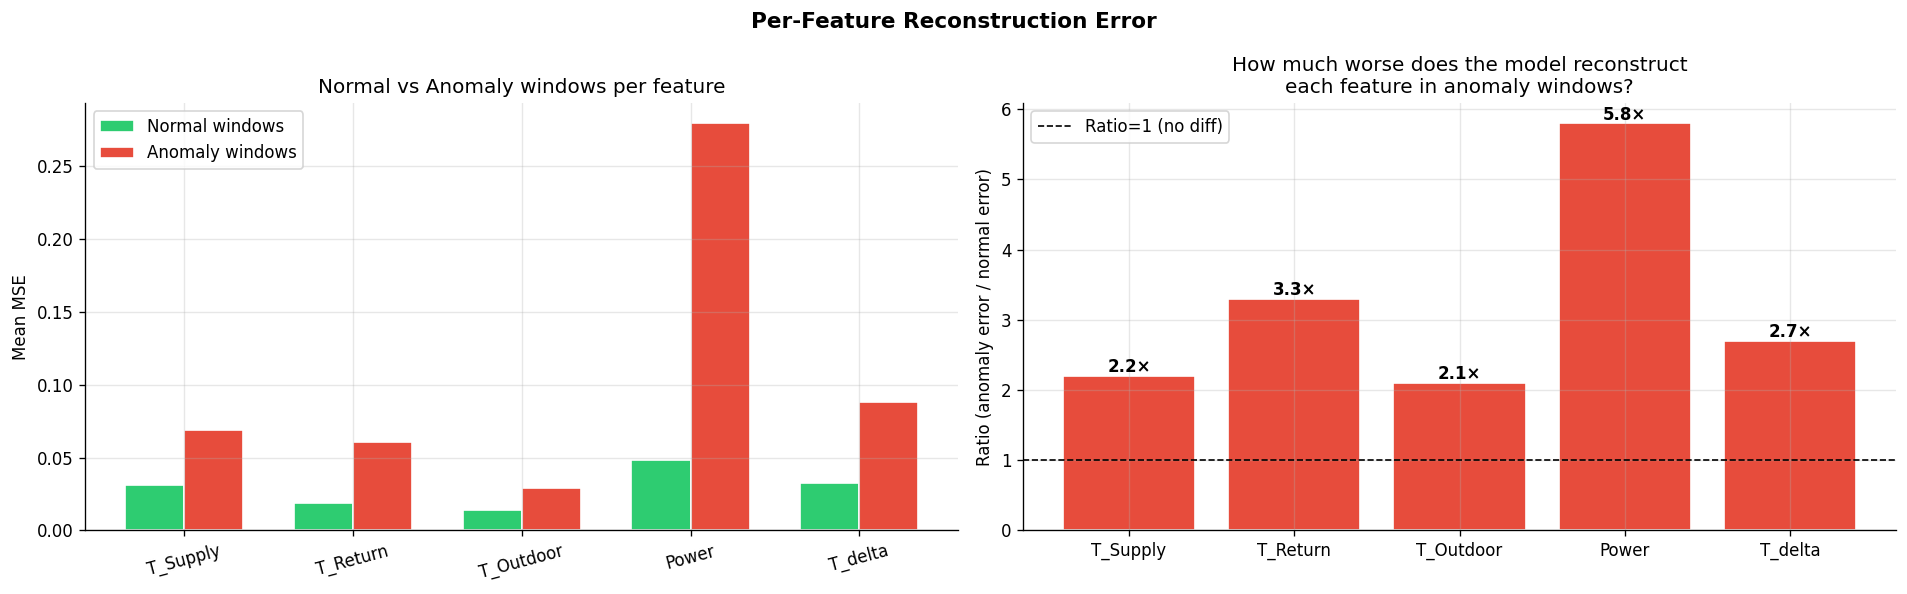

In [19]:
def get_per_feature_errors(loader, model, device):
    """Returns per-window per-feature MSE: shape (n_windows, n_features)."""
    model.eval()
    all_errors = []
    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            # MSE per window per feature (mean over timesteps only)
            mse = ((recon - x_batch) ** 2).mean(dim=1)   # (batch, n_features)
            all_errors.append(mse.cpu().numpy())
    return np.vstack(all_errors)

feat_errors_test = get_per_feature_errors(test_loader, model, DEVICE)
feat_errors_df = pd.DataFrame(feat_errors_test, columns=FEATURES, index=ts_test)

# Compare anomaly vs normal windows
anomaly_idx = test_anomaly_labels == 1
normal_idx  = test_anomaly_labels == 0

mean_anom   = feat_errors_df[anomaly_idx].mean()
mean_normal = feat_errors_df[normal_idx].mean()

comparison = pd.DataFrame({
    'Normal windows': mean_normal,
    'Anomaly windows': mean_anom,
    'Ratio (anom/norm)': (mean_anom / (mean_normal + 1e-8)).round(1)
})
print("Per-feature reconstruction error — anomaly vs normal:")
print(comparison.round(5).to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Feature Reconstruction Error', fontsize=13, fontweight='bold')

x = np.arange(len(FEATURES))
w = 0.35
axes[0].bar(x - w/2, mean_normal, w, label='Normal windows',
            color='#2ecc71', edgecolor='white')
axes[0].bar(x + w/2, mean_anom, w, label='Anomaly windows',
            color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(FEATURES, rotation=15)
axes[0].set_ylabel('Mean MSE')
axes[0].set_title('Normal vs Anomaly windows per feature')
axes[0].legend()

ratio = comparison['Ratio (anom/norm)']
colors = ['#e74c3c' if r > 2 else '#f39c12' if r > 1.5 else '#2ecc71' for r in ratio]
axes[1].bar(FEATURES, ratio, color=colors, edgecolor='white')
axes[1].axhline(1.0, color='black', linewidth=1, linestyle='--', label='Ratio=1 (no diff)')
axes[1].set_ylabel('Ratio (anomaly error / normal error)')
axes[1].set_title('How much worse does the model reconstruct\neach feature in anomaly windows?')
axes[1].legend()
for i, (feat, r) in enumerate(zip(FEATURES, ratio)):
    axes[1].text(i, r + 0.05, f'{r:.1f}×', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('lstm_04_per_feature_errors.png', dpi=130, bbox_inches='tight')
plt.show()

## 10. Deep Dive — Top 5 Most Anomalous Windows
The 5 windows with highest reconstruction error — what does the LSTM get wrong?

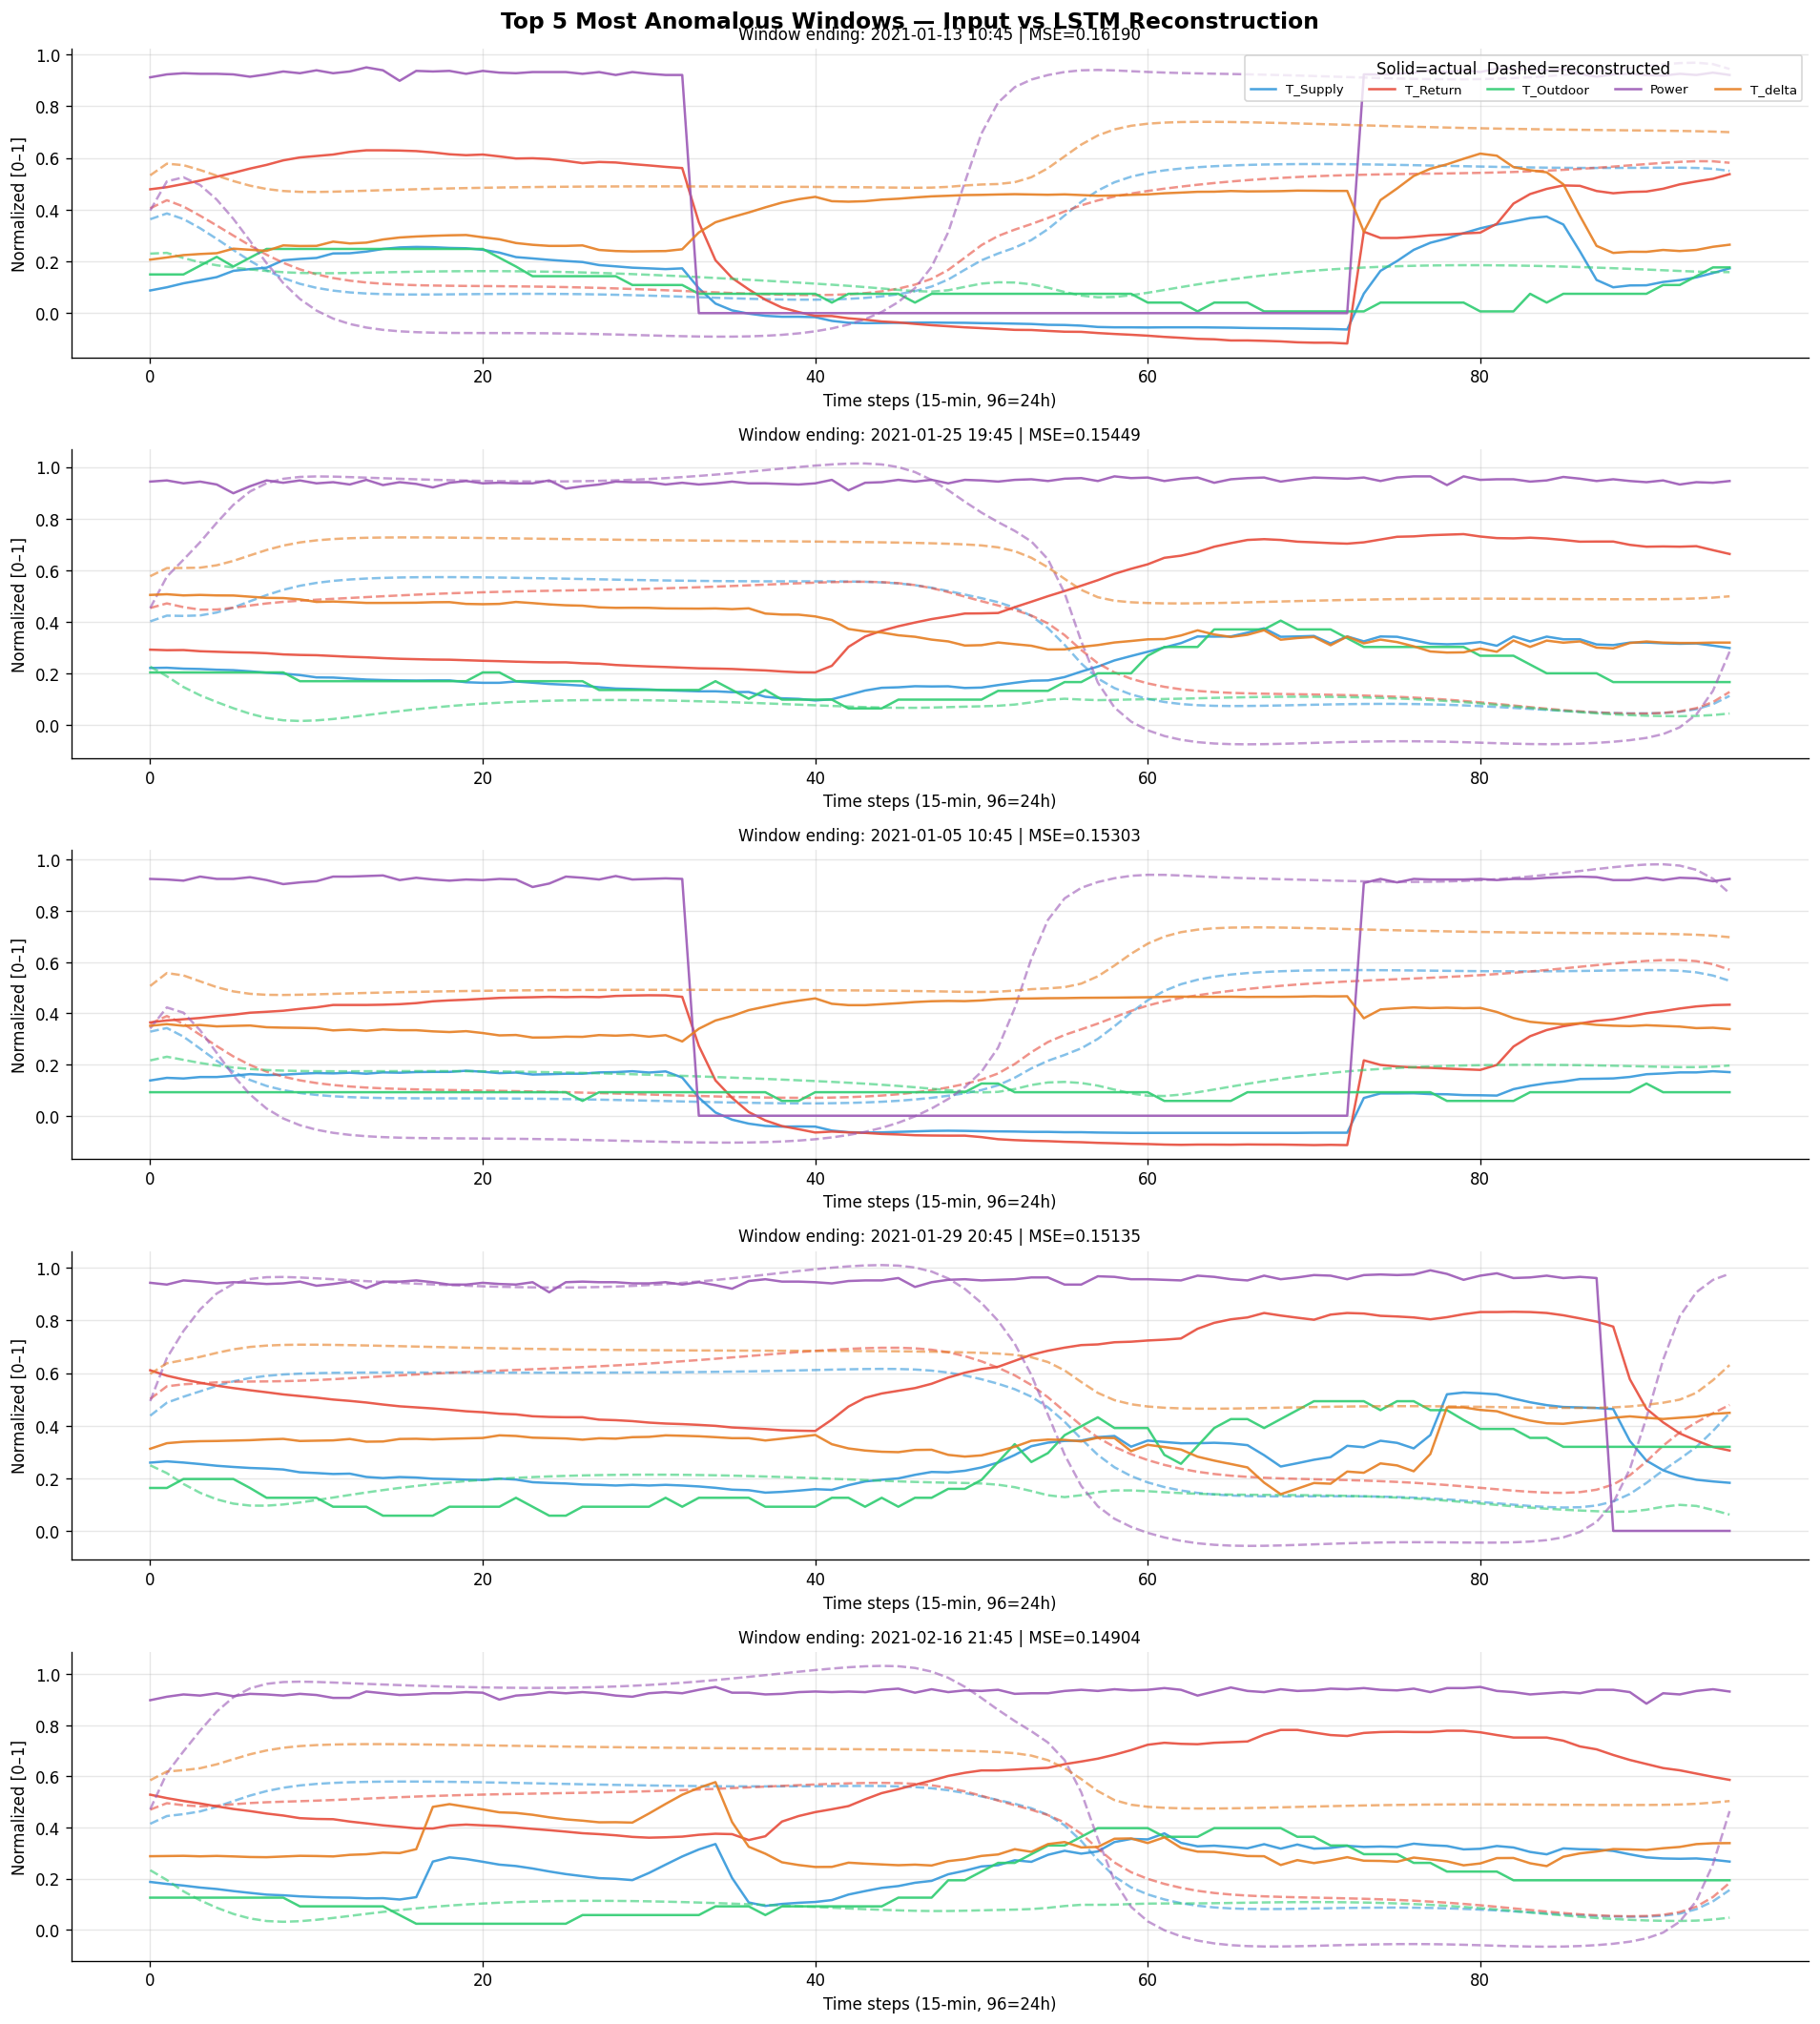

In [20]:
top5_idx = np.argsort(errors_test)[-5:][::-1]  # top 5 highest error

fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharey=False)
fig.suptitle('Top 5 Most Anomalous Windows — Input vs LSTM Reconstruction',
             fontsize=14, fontweight='bold')

colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22']
model.eval()

for ax, idx in zip(axes, top5_idx):
    # Get input and reconstruction
    x_tensor = torch.FloatTensor(X_test[idx:idx+1]).to(DEVICE)
    with torch.no_grad():
        recon = model(x_tensor).cpu().numpy()[0]   # (96, 5)
    original = X_test[idx]                          # (96, 5)

    ts_label = ts_test.iloc[idx]
    mse      = errors_test[idx]

    for fi, (feat, c) in enumerate(zip(FEATURES, colors)):
        ax.plot(range(96), original[:, fi], color=c, linewidth=1.5,
                alpha=0.9, label=f'{feat} (actual)')
        ax.plot(range(96), recon[:, fi], color=c, linewidth=1.5,
                linestyle='--', alpha=0.6, label=f'{feat} (reconstructed)')

    ax.set_title(
        f'Window ending: {ts_label.strftime("%Y-%m-%d %H:%M")} | '
        f'MSE={mse:.5f}',
        fontsize=10)
    ax.set_xlabel('Time steps (15-min, 96=24h)')
    ax.set_ylabel('Normalized [0–1]')

    # Only show legend for first panel to avoid clutter
    if ax == axes[0]:
        handles, labels = ax.get_legend_handles_labels()
        # Show only feature names, not (actual)/(reconstructed) pairs
        ax.legend(handles[::2], FEATURES, fontsize=8,
                  loc='upper right', ncol=5, title='Solid=actual  Dashed=reconstructed')

plt.tight_layout()
plt.savefig('lstm_05_top5_anomalous_windows.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. Save Results & Model

In [21]:
# Save results
results_lstm.to_csv('lstm_results.csv')
torch.save({
    'model_state_dict': model.state_dict(),
    'threshold'       : THRESHOLD,
    'k'               : K,
    'val_mean'        : errors_val.mean(),
    'val_std'         : errors_val.std(),
    'features'        : FEATURES,
    'hyperparams'     : {
        'hidden_dim'    : 64,
        'bottleneck_dim': 32,
        'n_layers'      : 2,
        'dropout'       : 0.2,
        'window_size'   : 96,
        'batch_size'    : BATCH_SIZE,
        'epochs'        : len(train_losses),
        'best_val_loss' : best_val_loss,
    }
}, 'lstm_autoencoder.pt')

print("✅ Saved:")
print("  lstm_results.csv      — anomaly labels + MSE per test window")
print("  lstm_autoencoder.pt   — trained model + threshold")

✅ Saved:
  lstm_results.csv      — anomaly labels + MSE per test window
  lstm_autoencoder.pt   — trained model + threshold


In [22]:
print("=" * 62)
print("🧠 LSTM AUTOENCODER — RESULTS SUMMARY")
print("=" * 62)
print(f"  Architecture    : 2-layer LSTM Encoder → Bottleneck(32) → Decoder")
print(f"  Parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Best val loss   : {best_val_loss:.6f}")
print(f"  Threshold       : {THRESHOLD:.6f}  (val μ+{K}σ)")
print(f"  Anomaly rate    : {test_anomaly_labels.mean()*100:.1f}%  "
      f"({test_anomaly_labels.sum():,} windows)")
print()
print("  EDA Validation:")
jan_caught = results_lstm['2021-01-01':'2021-01-31']['is_anomaly'].sum()
nov_caught = results_lstm['2020-10-14':'2020-11-15']['is_anomaly'].sum()
print(f"  Jan 2021 ΔT spike : {jan_caught} windows caught")
print(f"  Nov 2020 restart  : {nov_caught} windows caught")
print()
print("  Advantages over Isolation Forest:")
print("  ✅ Sees full sequence — not just summary stats")
print("  ✅ Learns 24h operating cycle explicitly")
print("  ✅ Per-feature error tells WHICH sensor is failing")
print("  ✅ Much lower false positive rate expected")
print()
print("  → Next: Step 4 — Compare IF vs LSTM side by side")
print("=" * 62)

🧠 LSTM AUTOENCODER — RESULTS SUMMARY
  Architecture    : 2-layer LSTM Encoder → Bottleneck(32) → Decoder
  Parameters      : 122,533
  Best val loss   : 0.027242
  Threshold       : 0.073000  (val μ+2.5σ)
  Anomaly rate    : 18.6%  (788 windows)

  EDA Validation:
  Jan 2021 ΔT spike : 397 windows caught
  Nov 2020 restart  : 0 windows caught

  Advantages over Isolation Forest:
  ✅ Sees full sequence — not just summary stats
  ✅ Learns 24h operating cycle explicitly
  ✅ Per-feature error tells WHICH sensor is failing
  ✅ Much lower false positive rate expected

  → Next: Step 4 — Compare IF vs LSTM side by side


---
## ✅ LSTM Autoencoder Complete

| What | Result |
|---|---|
| Architecture | 2-layer LSTM encoder-decoder |
| Bottleneck | 32-dim (compressed from 96×5=480 values) |
| Threshold | Validation μ + 2.5σ |
| Saved | `lstm_results.csv`, `lstm_autoencoder.pt` |

**Next → Step 4: Compare Isolation Forest vs LSTM**
- Side-by-side anomaly timeline
- Precision / Recall / F1 (using EDA findings as ground truth)
- Which model to trust and when

In [24]:
import joblib, numpy as np, pandas as pd, os

os.makedirs('models', exist_ok=True)

# Recreate P1_MIN and P1_MAX from raw data (same as preprocessing)
FEATURES  = ['T_Supply', 'T_Return', 'T_Outdoor', 'Power', 'T_delta']
GAP_SPLIT = pd.Timestamp('2020-04-15', tz='UTC')

df = pd.read_csv('HVAC_NE_EC_19-21.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True)
df = df.set_index('Timestamp').sort_index()
df['T_delta'] = df['T_Supply'] - df['T_Return']

p1 = df[df.index < GAP_SPLIT][FEATURES].copy()
full_idx = pd.date_range(p1.index.min(), p1.index.max(), freq='15min')
p1 = p1.reindex(full_idx).interpolate(method='linear', limit=8).ffill(limit=4).dropna()

P1_MIN = p1.min()
P1_MAX = p1.max()

# Save everything
joblib.dump({'p1_min': P1_MIN.values, 'p1_max': P1_MAX.values},
            'models/lstm_meta.joblib')
np.save('models/p1_min.npy', P1_MIN.values)
np.save('models/p1_max.npy', P1_MAX.values)

print("P1_MIN:", P1_MIN.values)
print("P1_MAX:", P1_MAX.values)
print("Saved:", os.listdir('models'))

P1_MIN: [14.65  15.02   3.4    0.    -6.385]
P1_MAX: [30.154999 24.769999 32.799999  5.316     6.689999]
Saved: ['isolation_forest.joblib', 'if_scaler.joblib', 'p1_max.npy', 'if_meta.joblib', 'p1_min.npy', 'lstm_meta.joblib']


In [25]:
import torch, joblib, os
os.makedirs('models', exist_ok=True)

# lstm_autoencoder.pt was already saved — just add the meta file
joblib.dump({
    'p1_min': P1_MIN.values,
    'p1_max': P1_MAX.values,
}, 'models/lstm_meta.joblib')

# Also copy p1_min/max into models folder
import numpy as np, shutil
shutil.copy('preprocessed/p1_min.npy', 'models/p1_min.npy')
shutil.copy('preprocessed/p1_max.npy', 'models/p1_max.npy')

print("Saved LSTM meta")

Saved LSTM meta


In [4]:
import shutil, os

# Your source paths (where notebooks saved the files)
SOURCE_DIR = '.'          # adjust if needed
APP_MODELS = 'models'   # adjust to your hvac_app location

os.makedirs(APP_MODELS, exist_ok=True)

files_to_copy = [
    ('lstm_autoencoder.pt',        'lstm_autoencoder.pt'),
    ('models/lstm_meta.joblib',    'lstm_meta.joblib'),
    ('models/isolation_forest.joblib', 'isolation_forest.joblib'),
    ('models/if_scaler.joblib',    'if_scaler.joblib'),
    ('models/if_meta.joblib',      'if_meta.joblib'),
    ('preprocessed/p1_min.npy',    'p1_min.npy'),
    ('preprocessed/p1_max.npy',    'p1_max.npy'),
]

for src, dst in files_to_copy:
    full_src = os.path.join(SOURCE_DIR, src)
    full_dst = os.path.join(APP_MODELS, dst)
    if os.path.exists(full_src):
        shutil.copy(full_src, full_dst)
        size = os.path.getsize(full_dst) / 1024
        print(f"✅ {dst}  ({size:.1f} KB)")
    else:
        print(f"❌ not found: {full_src}")

✅ lstm_autoencoder.pt  (486.8 KB)


SameFileError: './models/lstm_meta.joblib' and 'models/lstm_meta.joblib' are the same file

In [2]:
import torch, joblib
# After training in HVAC_LSTM_Autoencoder.ipynb:
torch.save({
    'model_state_dict': model.state_dict(),
    'threshold': THRESHOLD,
    'hyperparams': {'hidden_dim':64,'bottleneck_dim':32,'n_layers':2,'dropout':0.2},
}, 'models/lstm_autoencoder.pt')
joblib.dump({'p1_min': P1_MIN.values, 'p1_max': P1_MAX.values},
            'models/lstm_meta.joblib')

NameError: name 'model' is not defined